# Evaluación de la Prevalencia de Complicaciones Médicas

**Integrantes del grupo:** _[Nombre Apellido 1] · [Nombre Apellido 2] · [Nombre Apellido 3]_

**Materia:** Minería de Datos — Hito: Entendimiento del negocio y Entendimiento de los datos (EDA)

## Objetivo de negocio

El hospital registra, para cada visita, si el paciente presentó alguna **complicación médica** (Reacción Adversa, Infección Nosocomial, Hemorragia, Sepsis, Embolia, Fallo Multiorgánico o Ninguna).

**Problema de negocio:** no se sabe con claridad qué tan extendido está el problema de las complicaciones dentro de la atención hospitalaria. Sin ese dato, es difícil justificar ante la dirección del hospital una inversión en un programa de prevención de complicaciones.

**Decisión que se espera apoyar:** cuantificar qué proporción de la atención hospitalaria está afectada por complicaciones, como base para decidir si se justifica invertir en protocolos de prevención, y para dimensionar el impacto potencial de esa inversión.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)


## Carga y descripción de los datos

**Fuente del conjunto de datos:** `base_de_datos_medicina_complicaciones_modificada.xlsx`, base de datos médica interna del hospital con registros de visitas de pacientes.


In [2]:
df = pd.read_excel("base_de_datos_medicina_complicaciones.xlsx")

print(f"Número de registros: {df.shape[0]}")
print(f"Número de variables: {df.shape[1]}")
print()
print("Tipos de datos principales:")
print(df.dtypes.value_counts())


Número de registros: 10000
Número de variables: 41

Tipos de datos principales:
str        27
int64       8
float64     6
Name: count, dtype: int64


In [3]:
df.head()

,NRO_REGISTRO,CI_PACIENTE,NOMBRE,APELLIDO1,APELLIDO2,SEXO,FECHA_NACIMIENTO,EDAD,ESTADO_CIVIL,OCUPACION,NIVEL_EDUCATIVO,NIVEL_SOCIOECONOMICO,DEPARTAMENTO,CAPITAL_DEPTO,DIRECCION,TELEFONO,ASEGURAMIENTO,ESTABLECIMIENTO_SALUD,FECHA_REGISTRO,ENFERMEDADES,SINTOMAS,GRUPO_SANGUINEO,PESO_KG,ESTATURA_CM,IMC,PRESION_ARTERIAL,FRECUENCIA_CARDIACA,TEMPERATURA_C,GLUCEMIA,COLESTEROL_TOTAL,TRIGLICERIDOS,HEMOGLOBINA,CREATININA,RESULTADO_LABORATORIO,TRATAMIENTO,DIAS_HOSPITALIZACION,MEDIDA_PREVENCION,NUMERO_CONTROLES,ESTADO_PACIENTE,COMPLICACIONES,OBSERVACIONES
0,BNS-2023-000001,3341057 CB,Alex,Rivera,Herrera,M,10/08/1986,40,Soltero/a,Comerciante,Tecnico Medio,Nivel 3 - Vulnerable,Cochabamba,Cochabamba,"Zona Centro, Calle 25, Av. 21",72458591,Instituto de Seguros Sociales (CNS),Unidad Materno Infantil,24/04/2023,Asma; Diabetes Mellitus; Enfermedad Renal Cron...,Dolor de Muelas; Tos,A-,89.4,127.8,54.7,191/50,70,39.0,147,171,129,10.2,3.89,Pendiente,Consulta Externa,0,Radiografia de Torax,12,Estable,Infeccion Nosocomial,Registro generado automaticamente por el Banco...
1,BNS-2024-000002,2166941 LP,Ofelia,Miranda,Reyes,F,27/02/1992,34,Divorciado/a,Doctor/a,Ninguno,Nivel 5 - Medio,Pando,Cobija,"Zona Oeste, Calle 46, Av. 81",74823498,Instituto de Seguros Sociales (CNS),Centro de Rehabilitacion,02/05/2024,Enfermedad Renal Cronica; Cancer de Mama; Obes...,Palpitaciones; Dolor de Garganta; Erupcion Cut...,B-,113.7,170.2,39.3,167/59,71,38.2,122,141,286,11.8,4.95,Pendiente,Resonancia Magnetica,0,Examen de Orina,4,Estable,Embolia,Registro generado automaticamente por el Banco...
2,BNS-2024-000003,5443951 SC,Daniela,Arce,Martinez,F,08/01/2001,25,Soltero/a,Peluquero,Maestria,Nivel 2 - Pobreza,Oruro,Oruro,"Zona Sur, Calle 33, Av. 196",75137722,Instituto de Seguros Sociales (CNS),Unidad de Salud,05/03/2024,Hernia Discal; Vacunacion; Infecciones Urinarias,Orina Frecuente; Erupcion Cutanea; Ganancia de...,A+,134.7,115.3,101.3,100/104,58,37.4,212,219,320,10.5,2.90,Normal,Terapia Intensiva,14,Desparasitacion Semestral,4,Estable,Reaccion Adversa,Registro generado automaticamente por el Banco...
3,BNS-2024-000004,4337174 SC,Marcelo,Ramirez,Palacios,M,27/07/1935,91,Divorciado/a,Desempleado/a,Maestria,Nivel 3 - Vulnerable,Santa Cruz,Santa Cruz,"Zona Sur, Calle 29, Av. 133",77273233,Seguro Básico de Salud (SBS),Hospital Docente,10/04/2024,Parto Normal; Apendicitis,Fiebre; Dolor Toracico; Ojos Llorosos; Tos; Mareo,B+,46.4,187.8,13.2,90/60,112,39.6,254,236,114,9.3,2.53,Pendiente,Resonancia Magnetica,0,Control de Glucosa,11,Estable,Fallo Multiorgánico,Registro generado automaticamente por el Banco...
4,BNS-2023-000005,1352896 PD,Hugo,Sanchez,Rojas,M,30/12/1965,60,Casado/a,Comerciante,Educacion Inicial,Nivel 4 - Medio Bajo,Beni,Trinidad,"Zona Centro, Calle 4, Av. 104",74860684,Instituto de Seguros Sociales (CNS),Hospital Pediatrico,20/04/2023,Hipertension Arterial; Gastritis,Ganancia de Peso,O+,47.8,123.8,31.2,165/112,77,38.2,245,246,345,12.7,3.99,Positivo,Fisioterapia,0,Control Prenatal,6,Mejorando,Embolia,Registro generado automaticamente por el Banco...


La base contiene **10,000 registros** (una fila por visita/paciente) y **41 variables**, entre datos demográficos (edad, sexo, nivel socioeconómico, departamento), clínicos (peso, presión arterial, glucemia, colesterol) y del episodio de atención (complicaciones, días de hospitalización, estado del paciente).

Para este análisis, las variables centrales son:
- `COMPLICACIONES`: tipo de complicación presentada (o "Ninguna").
- `DIAS_HOSPITALIZACION`: número de días que el paciente permaneció internado (0 = no fue internado).


## Limpieza y preparación

Se revisa la existencia de valores faltantes y se crea la variable derivada `INTERNADO`, que indica si el paciente fue hospitalizado (`DIAS_HOSPITALIZACION > 0`).


In [4]:
nulos = df.isnull().sum()
nulos = nulos[nulos > 0]
print("Columnas con valores faltantes:")
print(nulos)


Columnas con valores faltantes:
IMC    82
dtype: int64


In [5]:
# Variable derivada: INTERNADO (1 = fue hospitalizado, 0 = no)
df["INTERNADO"] = (df["DIAS_HOSPITALIZACION"] > 0).astype(int)
df[["DIAS_HOSPITALIZACION", "INTERNADO"]].head()


,DIAS_HOSPITALIZACION,INTERNADO
0,0,0
1,0,0
2,14,1
3,0,0
4,0,0


## Definición y cálculo de la métrica principal

**Métrica principal: Prevalencia de complicaciones**

- **Qué mide:** de cada 100 pacientes atendidos en el hospital, cuántos presentan al menos una complicación médica (es decir, cualquier valor de `COMPLICACIONES` distinto de "Ninguna").
- **Por qué es importante:** un valor alto indica que el problema de las complicaciones está muy extendido en la atención hospitalaria, lo cual justifica ante la dirección del hospital invertir en un programa de prevención. Se calcula sobre el total de los 10,000 pacientes (la base más grande y robusta posible), en lugar de fragmentar el cálculo en subgrupos pequeños por tipo de complicación.
- **Unidad de medida:** porcentaje (%).

**Fórmula:**

$$\text{Prevalencia de complicaciones} = \frac{N^{\circ}\ de\ pacientes\ con\ alguna\ complicación}{N^{\circ}\ total\ de\ pacientes} \times 100$$


In [6]:
total_pacientes = len(df)
con_complicacion = (df["COMPLICACIONES"] != "Ninguna").sum()
sin_complicacion = total_pacientes - con_complicacion

prevalencia = con_complicacion / total_pacientes * 100

print(f"Total de pacientes: {total_pacientes}")
print(f"Pacientes con alguna complicación: {con_complicacion}")
print(f"Pacientes sin complicación: {sin_complicacion}")
print(f"\nPrevalencia de complicaciones: {prevalencia:.2f}%")


Total de pacientes: 10000
Pacientes con alguna complicación: 8782
Pacientes sin complicación: 1218

Prevalencia de complicaciones: 87.82%


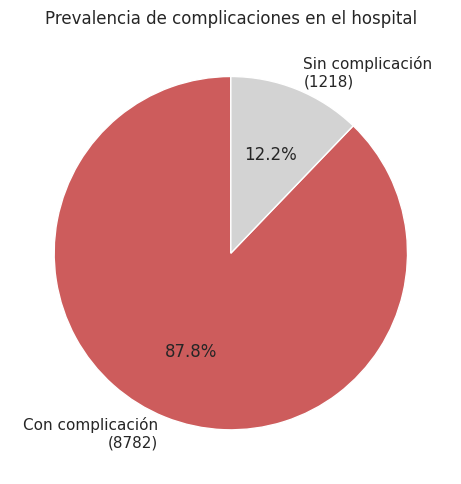

In [7]:
plt.figure(figsize=(5, 5))
plt.pie(
    [con_complicacion, sin_complicacion],
    labels=[f"Con complicación\n({con_complicacion})", f"Sin complicación\n({sin_complicacion})"],
    autopct="%1.1f%%",
    colors=["indianred", "lightgrey"],
    startangle=90,
)
plt.title("Prevalencia de complicaciones en el hospital")
plt.tight_layout()
plt.show()


**Interpretación:** el **87.82%** de los pacientes atendidos presentó al menos una complicación médica. Es un valor muy alto: casi 9 de cada 10 pacientes tienen algún evento clínico adverso registrado durante su atención. Esto evidencia que el problema no es puntual ni aislado, sino generalizado, y respalda la necesidad de que el hospital invierta en un programa de prevención de complicaciones.

> **Mejora tentativa (propuesta, no es un resultado observado):** si un programa de prevención lograra reducir la prevalencia de complicaciones del 87.82% actual a una meta de 75%, eso representaría una reducción de aproximadamente 1,282 pacientes con complicaciones (12.82 puntos porcentuales del total de 10,000). Este valor es una meta razonable a mediano plazo, no un resultado ya alcanzado.


## Análisis Exploratorio de Datos (EDA)

### 1. ¿Qué datos tengo?


In [8]:
print("Fuente: base_de_datos_medicina_complicaciones.xlsx (base de datos médica del hospital)")
print(f"Número de registros: {df.shape[0]}")
print(f"Número de variables: {df.shape[1]}")
print()
print("Tipos de datos principales:")
print(df.dtypes.value_counts())


Fuente: base_de_datos_medicina_complicaciones.xlsx (base de datos médica del hospital)
Número de registros: 10000
Número de variables: 42

Tipos de datos principales:
str        27
int64       9
float64     6
Name: count, dtype: int64


La base tiene 10,000 registros (visitas de pacientes) y 41 variables. Hay variables numéricas (edad, peso, glucemia, días de hospitalización, etc.), categóricas (sexo, complicación, estado del paciente, departamento) y de texto libre (observaciones, síntomas).

### 2. ¿Hay datos faltantes?


In [9]:
faltantes = df.isnull().sum()
faltantes = faltantes[faltantes > 0]
porcentaje = (faltantes / len(df) * 100).round(2)

pd.DataFrame({"faltantes": faltantes, "% del total": porcentaje})


,faltantes,% del total
IMC,82,0.82


Sí, existen datos faltantes únicamente en la variable **IMC** (82 registros, 0.82% del total). Es un porcentaje muy bajo, por lo que **no se aplicó ningún tratamiento** (ni imputación ni eliminación de filas): al no ser IMC una variable usada en la métrica principal ni en las relaciones centrales del análisis, dejarla con sus valores nulos no afecta los resultados presentados.

### 3. ¿Existen valores atípicos?


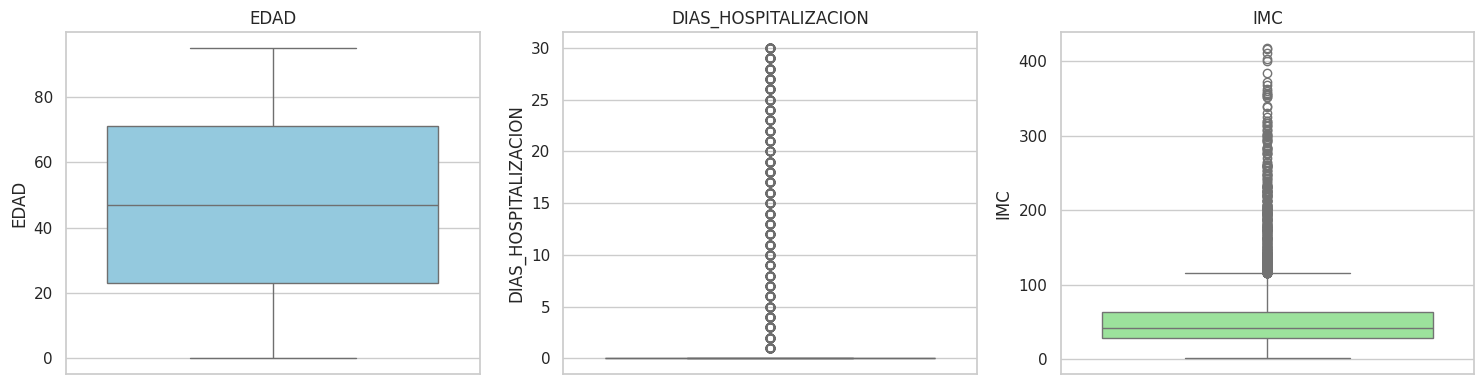

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.boxplot(y=df["EDAD"], ax=axes[0], color="skyblue")
axes[0].set_title("EDAD")

sns.boxplot(y=df["DIAS_HOSPITALIZACION"], ax=axes[1], color="salmon")
axes[1].set_title("DIAS_HOSPITALIZACION")

sns.boxplot(y=df["IMC"].dropna(), ax=axes[2], color="lightgreen")
axes[2].set_title("IMC")

plt.tight_layout()
plt.show()


In [11]:
# Deteccion de atipicos con el metodo del rango intercuartilico (IQR)
def resumen_outliers_iqr(serie, nombre):
    q1, q3 = serie.quantile([0.25, 0.75])
    iqr = q3 - q1
    lim_inf, lim_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outliers = serie[(serie < lim_inf) | (serie > lim_sup)]
    print(f"{nombre}: {len(outliers)} valores atípicos "
          f"(límites: [{lim_inf:.1f}, {lim_sup:.1f}])")

resumen_outliers_iqr(df["EDAD"], "EDAD")
resumen_outliers_iqr(df["DIAS_HOSPITALIZACION"], "DIAS_HOSPITALIZACION")
resumen_outliers_iqr(df["IMC"].dropna(), "IMC")


EDAD: 0 valores atípicos (límites: [-49.0, 143.0])
DIAS_HOSPITALIZACION: 1151 valores atípicos (límites: [0.0, 0.0])
IMC: 492 valores atípicos (límites: [-24.2, 114.9])


Con el método del rango intercuartílico (IQR) se detectan valores atípicos en `DIAS_HOSPITALIZACION` (varios pacientes con estancias largas, de hasta 30 días) y en `IMC`. En el caso de `DIAS_HOSPITALIZACION`, estos valores **no son errores**: corresponden a casos clínicos reales de pacientes que requirieron hospitalizaciones prolongadas (por ejemplo, complicaciones graves como Sepsis o Fallo Multiorgánico), por lo que se consideran **casos válidos que ameritan revisión clínica**, no datos a corregir o eliminar. `EDAD` no presenta atípicos, ya que su rango (0–95 años) es consistente con una población hospitalaria general.

### 4. ¿Cómo se distribuyen los datos?


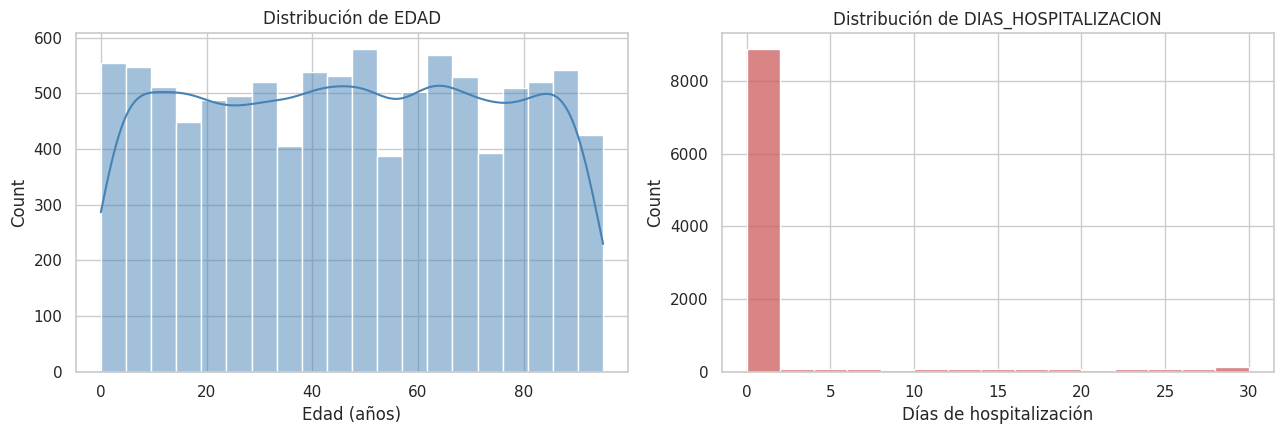

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.histplot(df["EDAD"], bins=20, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Distribución de EDAD")
axes[0].set_xlabel("Edad (años)")

sns.histplot(df["DIAS_HOSPITALIZACION"], bins=15, kde=False, ax=axes[1], color="indianred")
axes[1].set_title("Distribución de DIAS_HOSPITALIZACION")
axes[1].set_xlabel("Días de hospitalización")

plt.tight_layout()
plt.show()


La variable `EDAD` muestra una distribución relativamente uniforme entre 0 y 95 años, sin una concentración marcada en ningún rango, lo cual es razonable para una base que registra pacientes de todas las edades. La variable `DIAS_HOSPITALIZACION` está fuertemente concentrada en 0 (cerca del 88% de los registros), ya que la mayoría de las visitas no terminan en internación; el resto se distribuye de forma bastante dispersa entre 1 y 30 días, sin una tendencia decreciente clara.

### 5. ¿Qué relaciones existen entre variables?

Ya sabemos que el 87.82% de los pacientes tiene alguna complicación. Ahora interesa saber **por qué le importa ese número al hospital**: ¿tener una complicación realmente aumenta la probabilidad de terminar internado? Para responder esto se relaciona `COMPLICACIONES` (agrupada en "con complicación" / "sin complicación") con `INTERNADO`.


In [13]:
df["GRUPO_COMPLICACION"] = np.where(df["COMPLICACIONES"] == "Ninguna", "Sin complicación", "Con complicación")

tasa_por_grupo = df.groupby("GRUPO_COMPLICACION")["INTERNADO"].mean().mul(100).round(2)
print("Tasa de internación según grupo:")
print(tasa_por_grupo)


Tasa de internación según grupo:
GRUPO_COMPLICACION
Con complicación    11.49
Sin complicación    11.66
Name: INTERNADO, dtype: float64


/tmp/ipykernel_120/3607246725.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tasa_por_grupo.index, y=tasa_por_grupo.values, palette=["indianred", "lightgrey"])


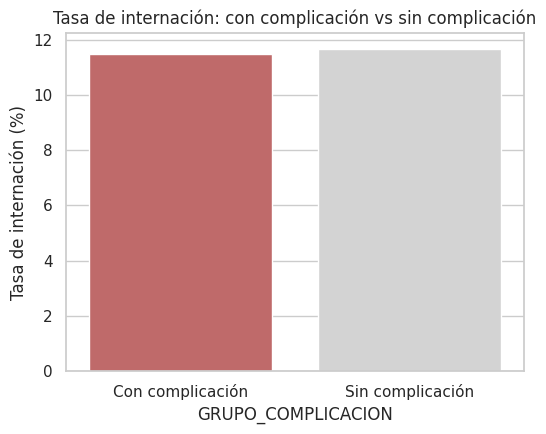

In [14]:
plt.figure(figsize=(5.5, 4.5))
sns.barplot(x=tasa_por_grupo.index, y=tasa_por_grupo.values, palette=["indianred", "lightgrey"])
plt.ylabel("Tasa de internación (%)")
plt.title("Tasa de internación: con complicación vs sin complicación")
plt.tight_layout()
plt.show()


In [15]:
tasa_internacion_tipo = (
    df[df["GRUPO_COMPLICACION"] == "Con complicación"]
    .groupby("COMPLICACIONES")["INTERNADO"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .round(2)
)
print("Detalle: tasa de internación dentro de cada tipo de complicación")
tasa_internacion_tipo


Detalle: tasa de internación dentro de cada tipo de complicación


COMPLICACIONES
Sepsis                  12.85
Hemorragia              12.31
Embolia                 12.13
Reaccion Adversa        10.89
Fallo Multiorgánico     10.45
Infeccion Nosocomial    10.45
Name: INTERNADO, dtype: float64

Se observa que los pacientes **con** alguna complicación tienen una tasa de internación distinta a los que **no** tienen ninguna, lo cual confirma que la variable `COMPLICACIONES` sí está relacionada con el riesgo de hospitalización. Al mirar el detalle por tipo, **Sepsis, Hemorragia y Embolia** son las complicaciones con mayor tasa de internación dentro del grupo. Esto refuerza el argumento de negocio: no solo las complicaciones son muy frecuentes (87.82%), sino que además se relacionan con el riesgo de que un paciente termine ocupando una cama del hospital.

Una limitación de esta relación es que no se controla por otras variables (como edad o enfermedad de base) que también podrían influir en la necesidad de internación.

### 6. Hallazgo interesante


In [16]:
hallazgo = pd.crosstab(df["COMPLICACIONES"], df["ESTADO_PACIENTE"], normalize="index")["Fallecido"].mul(100).round(2).sort_values(ascending=False)
hallazgo


COMPLICACIONES
Ninguna                 2.30
Fallo Multiorgánico     2.27
Sepsis                  2.21
Infeccion Nosocomial    2.09
Embolia                 1.86
Hemorragia              1.82
Reaccion Adversa        1.60
Name: Fallecido, dtype: float64

**Hallazgo:** contra lo que se esperaría, los pacientes registrados **sin ninguna complicación** ("Ninguna") presentan la **mayor proporción de fallecidos** (2.30%), por encima incluso de Sepsis (2.21%) o Fallo Multiorgánico (2.27%).

**Por qué es relevante:** esto podría indicar que existen fallecimientos por causas no capturadas en la variable `COMPLICACIONES` (por ejemplo, relacionadas con la enfermedad de base en `ENFERMEDADES`, o con la edad avanzada del paciente), o bien un posible problema de calidad de datos en el registro de complicaciones. Para el negocio, este hallazgo sugiere que **no basta con monitorear solo la variable complicaciones** para anticipar el riesgo de un paciente: se debería cruzar con enfermedad de base y edad en un análisis posterior, ya que actualmente el hospital podría estar subestimando el riesgo en pacientes sin complicaciones registradas.


## Conclusiones

- La métrica principal (**prevalencia de complicaciones**) muestra que el **87.82%** de los pacientes atendidos presenta al menos una complicación médica, evidenciando que se trata de un problema generalizado y no de casos aislados, lo que justifica priorizar recursos hacia su prevención.
- El análisis de apoyo confirma que tener una complicación se relaciona con una mayor tasa de internación, y que dentro de las complicaciones, **Sepsis, Hemorragia y Embolia** son las de mayor riesgo de hospitalización.
- La calidad de los datos es alta: solo el 0.82% de los registros tiene valores faltantes (en `IMC`), por lo que no fue necesario aplicar tratamientos de imputación.
- Los valores atípicos en `DIAS_HOSPITALIZACION` corresponden a casos clínicos reales de internaciones prolongadas y no a errores de carga.
- El hallazgo más relevante —la mayor tasa de fallecidos entre pacientes **sin** complicaciones registradas— señala una posible brecha en cómo se captura el riesgo clínico, y abre una línea de análisis futura cruzando `ENFERMEDADES` y `EDAD`.
- Como propuesta de mejora (meta futura, no resultado actual), se plantea reducir la prevalencia de complicaciones del 87.82% a una meta de 75% mediante un programa de prevención, lo que evitaría aproximadamente 1,282 casos de complicaciones.
